## Observation Planning for proposals 

CTAO will conduct observations based on competitive proposals requesting time. 
This tutorial will enable you to complete the sections of an observation proposal concerning the observation parameters and the technical justification.

To start with, we assume that you already know a) the science case for gamma-ray emission, b) a specific target located on the sky, and c) the anticipated gamma-ray flux. 

We will now address the following questions:
1. Is the source visible by CTAO-N/CTAO-S?
2. How much time do I need to reach a 5$\sigma$ detection?
3. What role do the zenith angle and Night Sky Background play? 
4. How do I determine a good observation strategy?
5. What total observation time should be requested? 

### 3: zenith

In this notebook we investigate the influence of zenith angle on sensitivity. 

As an example, we are considering the LST sub-array (4xLST at CTAO-N) IRFs from the CTA official set: [CTA_prod5-IRFs_Zenodo](https://zenodo.org/doi/10.5281/zenodo.5499839)


In [1]:
#First import some useful packages
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u

from gammapy.estimators import SensitivityEstimator
from gammapy.irf import load_irf_dict_from_file

%matplotlib inline

In [2]:
#Extract the FITS files and give the path to where they are located for you at 20, 40 and 60 degrees zenith angle
filepath = "/shared/ALICE_2026/fits/"
# /Users/amwmitchell/Documents/CTA/cta-prod5-zenodo-fitsonly-v0.1/fits/"

file20 = "Prod5-North-20deg-AverageAz-4LSTs.180000s-v0.1.fits"
# CTA-Performance-prod5-v0.1-North-LSTSubArray-20deg.FITS/Prod5-North-20deg-AverageAz-4LSTs.180000s-v0.1.fits"
file40 = "Prod5-North-40deg-AverageAz-4LSTs.180000s-v0.1.fits"
# CTA-Performance-prod5-v0.1-North-LSTSubArray-40deg.FITS/Prod5-North-40deg-AverageAz-4LSTs.180000s-v0.1.fits"
file60 = "Prod5-North-60deg-AverageAz-4LSTs.180000s-v0.1.fits"
#CTA-Performance-prod5-v0.1-North-LSTSubArray-60deg.FITS/Prod5-North-60deg-AverageAz-4LSTs.180000s-v0.1.fits"

IRFs20 = load_irf_dict_from_file(filepath+file20)
IRFs40 = load_irf_dict_from_file(filepath+file40)
IRFs60 = load_irf_dict_from_file(filepath+file60)

/opt/anaconda/envs/fermi/lib/python3.11/site-packages/gammapy/irf/background.py:445: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(offset_axis.center, bkg, label=label, **kwargs)
/opt/anaconda/envs/fermi/lib/python3.11/site-packages/gammapy/irf/background.py:485: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(energy_axis.center, bkg, label=label, **kwargs)


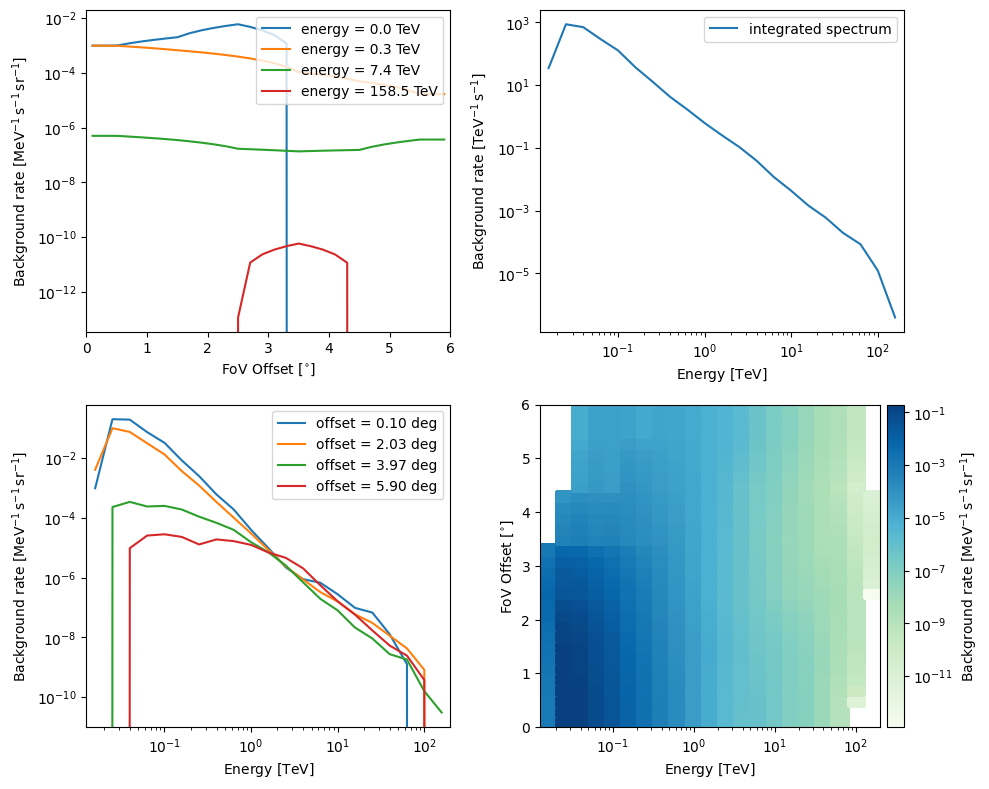

In [3]:
#Take a look at the background
IRFs20["bkg"].peek()

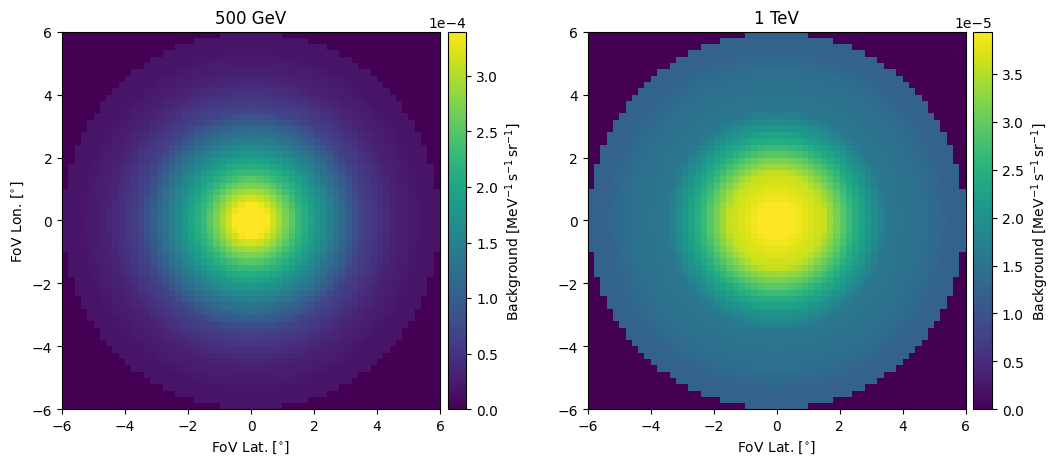

In [4]:
#Take a look at the background map
IRFs20["bkg"].plot_at_energy(["500 GeV","1 TeV"])

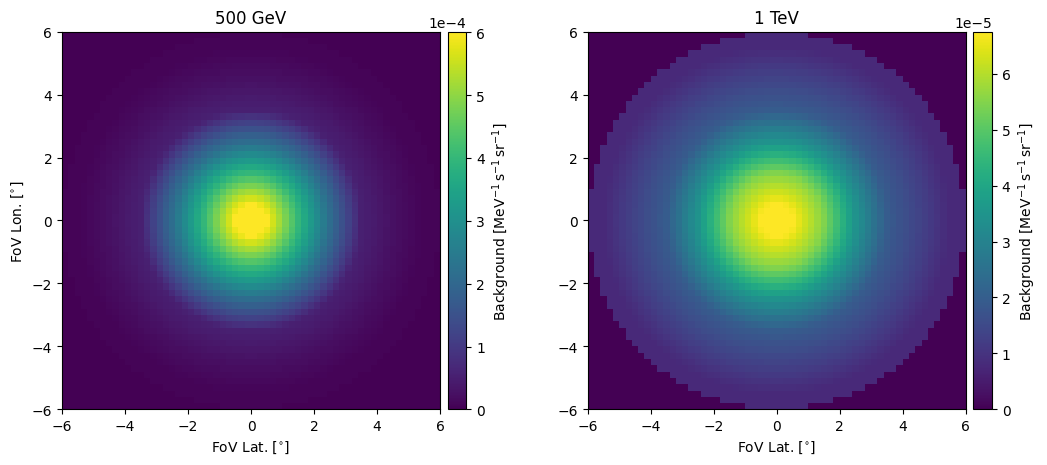

In [5]:
#Take a look at the background map
IRFs40["bkg"].plot_at_energy(["500 GeV","1 TeV"])

In [6]:
# IRFs60["bkg"].to_table_hdu().header

In [7]:
#Evaluate the background map at 1 degree offset at different zenith angles
print("20 deg",IRFs20["bkg"].evaluate(energy="1 TeV", fov_lon="1 deg", fov_lat="0 deg"))
print("40 deg",IRFs40["bkg"].evaluate(energy="1 TeV", fov_lon="1 deg", fov_lat="0 deg"))
print("60 deg",IRFs60["bkg"].evaluate(energy="1 TeV", fov_lon="1 deg", fov_lat="0 deg"))

20 deg 3.7612692368645006e-05 1 / (MeV s sr)
40 deg 6.112422000054424e-05 1 / (MeV s sr)
60 deg 0.00018564172920253823 1 / (MeV s sr)


### Compare background curves

To compare the background curves at different zenith angles, we can look at the fits files using astropy.
We compare the background at 0.0 and at 1.0 degree offset. 

In [8]:
from astropy.io import fits

In [9]:
hdul = fits.open(filepath+file20)
hdul.info()

Filename: /shared/ALICE_2026/fits/Prod5-North-20deg-AverageAz-4LSTs.180000s-v0.1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       9   ()      
  1  EFFECTIVE AREA    1 BinTableHDU     37   1R x 5C   [42E, 42E, 6E, 6E, 252E]   
  2  POINT SPREAD FUNCTION    1 BinTableHDU     55   1R x 10C   [21E, 21E, 6E, 6E, 126E, 126E, 126E, 126E, 126E, 126E]   
  3  ENERGY DISPERSION    1 BinTableHDU     40   1R x 7C   [300E, 300E, 300E, 300E, 6E, 6E, 540000E]   
  4  BACKGROUND    1 BinTableHDU     44   1R x 7C   [21E, 21E, 60E, 60E, 60E, 60E, 75600E]   


In [10]:
hdul[4].columns

ColDefs(
    name = 'ENERG_LO'; format = '21E'; unit = 'TeV'
    name = 'ENERG_HI'; format = '21E'; unit = 'TeV'
    name = 'DETX_LO'; format = '60E'; unit = 'deg'
    name = 'DETX_HI'; format = '60E'; unit = 'deg'
    name = 'DETY_LO'; format = '60E'; unit = 'deg'
    name = 'DETY_HI'; format = '60E'; unit = 'deg'
    name = 'BKG'; format = '75600E'; unit = 's^-1 MeV^-1 sr^-1'; dim = '(21,60,60)'
)

In [11]:
hdul4 = fits.open(filepath+file40)
hdul6 = fits.open(filepath+file60)

In [12]:
en_tst = 0.5*(hdul[4].data["ENERG_HI"] - hdul[4].data["ENERG_LO"])[0]
en4_tst = 0.5*(hdul4[4].data["ENERG_HI"] - hdul4[4].data["ENERG_LO"])[0]
en6_tst = 0.5*(hdul6[4].data["ENERG_HI"] - hdul6[4].data["ENERG_LO"])[0]

In [13]:
ind_lo = np.where(hdul[4].data["DETX_LO"][0]==0.0)[0][0]
ind_hi = np.where(hdul[4].data["DETX_HI"][0]==0.0)[0][0]
ind1lo = np.where(hdul[4].data["DETX_LO"][0]==1.0)[0][0]
ind1hi = np.where(hdul[4].data["DETX_HI"][0]==1.0)[0][0]

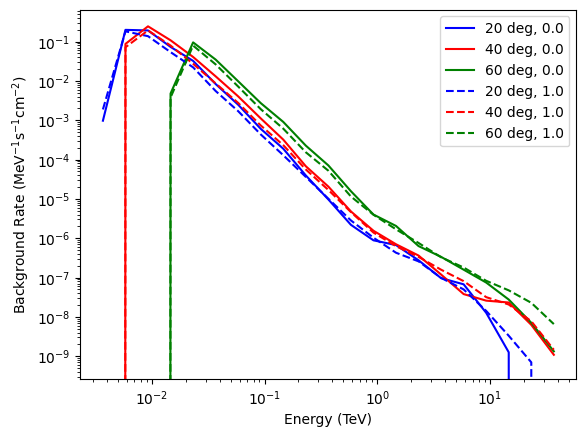

In [14]:
#Plot the background rate for different zenith angles and offsets

plt.plot(en_tst,hdul[4].data["BKG"][0][ind_lo][ind_hi],label="20 deg, 0.0",color="b")
plt.plot(en4_tst,hdul4[4].data["BKG"][0][ind_lo][ind_hi],label="40 deg, 0.0",color="r")
plt.plot(en6_tst,hdul6[4].data["BKG"][0][ind_lo][ind_hi],label="60 deg, 0.0",color="g")

plt.plot(en_tst,hdul[4].data["BKG"][0][ind1lo][ind1hi],label="20 deg, 1.0",linestyle="--",color="b")
plt.plot(en4_tst,hdul4[4].data["BKG"][0][ind1lo][ind1hi],label="40 deg, 1.0",linestyle="--",color="r")
plt.plot(en6_tst,hdul6[4].data["BKG"][0][ind1lo][ind1hi],label="60 deg, 1.0",linestyle="--",color="g")


plt.semilogx()
plt.semilogy()
plt.ylabel("Background Rate (MeV$^{-1}$s$^{-1}$cm$^{-2}$)")
plt.xlabel("Energy (TeV)")
plt.legend()

# plt.savefig("BkgRateZenith4LST.png")

None

Here we can see that with increasing zenith angle, the energy threshold increases and the normalisation of the background rate increases. At one degree offset the background rate does not change significantly. 

### Effective area for different offsets and zenith angles

/opt/anaconda/envs/fermi/lib/python3.11/site-packages/gammapy/irf/effective_area.py:103: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(energy_axis.center, area, label=label, **kwargs)


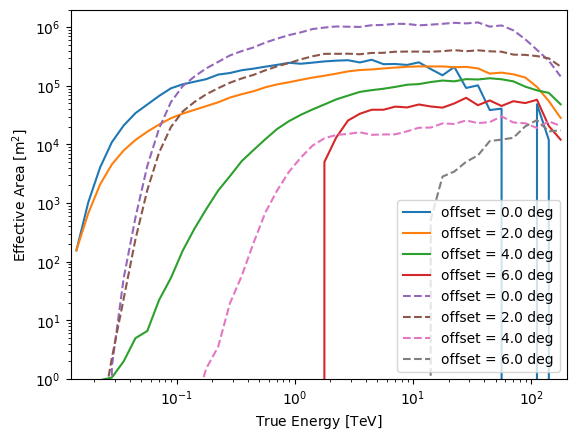

In [15]:
IRFs20["aeff"].plot_energy_dependence()
IRFs60["aeff"].plot_energy_dependence(ls="--")
plt.semilogy()
plt.ylim([1.,2e6])

# plt.savefig("EffectiveArea4LST.png")

None

Here we see that the energy threshold increases both with zenith angle and with offset. The effective area decreases with offset angle, but increases at high energies with zenith angle for lower offsets. 

## Point Spread Function (PSF)

This is stored in a parameterised form, typically either a triple Gaussian: 

$ \frac{dP}{d\Omega}\left(r,S,\sigma_1,A_2,\sigma_2,A_3,\sigma_3\right) = \frac{S}{\pi}\left[\exp\left(\frac{-r^2}{2\sigma_1^2}\right)+A_2\exp\left(\frac{-r^2}{2\sigma_2^2}\right)+A_3\exp\left(\frac{-r^2}{2\sigma_3^2}\right)\right]$

or a King function.


In [16]:
hdul[2].columns

ColDefs(
    name = 'ENERG_LO'; format = '21E'; unit = 'TeV'
    name = 'ENERG_HI'; format = '21E'; unit = 'TeV'
    name = 'THETA_LO'; format = '6E'; unit = 'deg'
    name = 'THETA_HI'; format = '6E'; unit = 'deg'
    name = 'SCALE'; format = '126E'; unit = 'sr^(-1)'; dim = '(21,6)'
    name = 'SIGMA_1'; format = '126E'; unit = 'deg'; dim = '(21,6)'
    name = 'SIGMA_2'; format = '126E'; unit = 'deg'; dim = '(21,6)'
    name = 'SIGMA_3'; format = '126E'; unit = 'deg'; dim = '(21,6)'
    name = 'AMPL_2'; format = '126E'; dim = '(21,6)'
    name = 'AMPL_3'; format = '126E'; dim = '(21,6)'
)

In [17]:
def triple_gauss(r,S,sig1,A2,sig2,A3,sig3):
    term1 = np.exp(-r**2/(2*sig1**2))
    term2 = 0.
    if sum(sig2):
        term2 = A2*np.exp(-r**2/(2*sig2**2))
    term3 = 0.
    if sum(sig3):
        term3 = A3*np.exp(-r**2/(2*sig3**2))

    psf = (S/np.pi)*(term1+term2+term3)
    
    return psf

In [18]:
en_psf = 0.5*(hdul[2].data["ENERG_HI"] - hdul[2].data["ENERG_LO"])[0]
en4_psf = 0.5*(hdul4[2].data["ENERG_HI"] - hdul4[2].data["ENERG_LO"])[0]
en6_psf = 0.5*(hdul6[2].data["ENERG_HI"] - hdul6[2].data["ENERG_LO"])[0]
print(len(en_psf))

21


In [19]:
triple_gauss(1.,hdul[2].data["SCALE"][0][1],hdul[2].data["SIGMA_1"][0][1],
             hdul[2].data["AMPL_2"][0][1],hdul[2].data["SIGMA_2"][0][1],
            hdul[2].data["AMPL_3"][0][1],hdul[2].data["SIGMA_3"][0][1])

/tmp/ipykernel_613/3259132096.py:2: RuntimeWarning: divide by zero encountered in divide
  term1 = np.exp(-r**2/(2*sig1**2))


array([1.1974669e-05, 1.1153596e-06, 5.4460529e-09, 6.6605223e-14,
       4.8689240e-21, 1.3774847e-29, 1.8570191e-38, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00], dtype=float32)

In [20]:
psf_20_0 = triple_gauss(0.1*np.ones(len(en_psf)),hdul[2].data["SCALE"][0][0],hdul[2].data["SIGMA_1"][0][0],
                        hdul[2].data["AMPL_2"][0][0],hdul[2].data["SIGMA_2"][0][0],
                        hdul[2].data["AMPL_3"][0][0],hdul[2].data["SIGMA_3"][0][0])
psf_40_0 = triple_gauss(0.1*np.ones(len(en4_psf)),hdul4[2].data["SCALE"][0][0],hdul4[2].data["SIGMA_1"][0][0],
                        hdul4[2].data["AMPL_2"][0][0],hdul4[2].data["SIGMA_2"][0][0],
                        hdul4[2].data["AMPL_3"][0][0],hdul4[2].data["SIGMA_3"][0][0])
psf_60_0 = triple_gauss(0.1*np.ones(len(en6_psf)),hdul6[2].data["SCALE"][0][0],hdul6[2].data["SIGMA_1"][0][0],
                        hdul6[2].data["AMPL_2"][0][0],hdul6[2].data["SIGMA_2"][0][0],
                        hdul6[2].data["AMPL_3"][0][0],hdul6[2].data["SIGMA_3"][0][0])
psf_20_1 = triple_gauss(0.1*np.ones(len(en_psf)),hdul[2].data["SCALE"][0][1],hdul[2].data["SIGMA_1"][0][1],
                        hdul[2].data["AMPL_2"][0][1],hdul[2].data["SIGMA_2"][0][1],
                        hdul[2].data["AMPL_3"][0][1],hdul[2].data["SIGMA_3"][0][1])
psf_40_1 = triple_gauss(0.1*np.ones(len(en4_psf)),hdul4[2].data["SCALE"][0][1],hdul4[2].data["SIGMA_1"][0][1],
                        hdul4[2].data["AMPL_2"][0][1],hdul4[2].data["SIGMA_2"][0][1],
                        hdul4[2].data["AMPL_3"][0][1],hdul4[2].data["SIGMA_3"][0][1])
psf_60_1 = triple_gauss(0.1*np.ones(len(en6_psf)),hdul6[2].data["SCALE"][0][1],hdul6[2].data["SIGMA_1"][0][1],
                        hdul6[2].data["AMPL_2"][0][1],hdul6[2].data["SIGMA_2"][0][1],
                        hdul6[2].data["AMPL_3"][0][1],hdul6[2].data["SIGMA_3"][0][1])


/tmp/ipykernel_613/3259132096.py:2: RuntimeWarning: divide by zero encountered in divide
  term1 = np.exp(-r**2/(2*sig1**2))


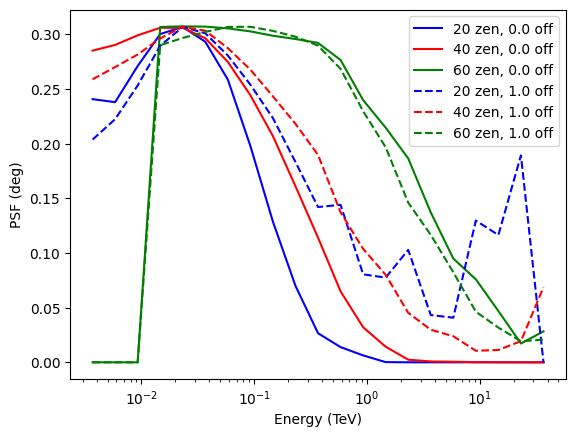

In [21]:
plt.plot(en_psf,psf_20_0,label="20 zen, 0.0 off",color="b")
plt.plot(en4_psf,psf_40_0,label="40 zen, 0.0 off",color="r")
plt.plot(en6_psf,psf_60_0,label="60 zen, 0.0 off",color="g")

plt.plot(en_psf,psf_20_1,label="20 zen, 1.0 off",linestyle="--",color="b")
plt.plot(en4_psf,psf_40_1,label="40 zen, 1.0 off",linestyle="--",color="r")
plt.plot(en6_psf,psf_60_1,label="60 zen, 1.0 off",linestyle="--",color="g")


plt.semilogx()

plt.ylabel("PSF (deg)")
plt.xlabel("Energy (TeV)")
plt.legend()

# plt.savefig("PSF_zenith.png")

None

**Task**: Try exploring how these IRFs change for different CTAO sites and telescope sub-arrays